# 4_eea
Check 'NULL' values counts for the columns 'co2_emissions_WLTP (g/km)', 'engine_capacity (cm3)', 'engine_power (KW)' and 'electric_energy_consumption (Wh/km)'

In [575]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import country_converter as coco
from itertools import chain

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df = spark.read.parquet(f"../data/4_eea_co2_emissions_from_passenger_cars-001.parquet")

### Redo preprocessing steps before cleaning to obtain 'NULL' counts.

Remap column names to more easily understandable ones

In [576]:
column_mapping = {
    "Country": "geo",
    "VFN": "vehicle_family_id_number",
    "Mh": "manufacturer_name_eu_standard_denomination",
    "T": "type",
    "Va": "variant",
    "Ve": "version",
    "Mk": "make",
    "Cn": "commercial_name",
    "m (kg)": "mass_in_running_order (kg)",
    "Ewltp (g/km)": "co2_emissions_WLTP (g/km)",
    "Ft": "Motor energy",
    "Fm": "fuel_mode",
    "ec (cm3)": "engine_capacity (cm3)",
    "ep (KW)": "engine_power (KW)",
    "z (Wh/km)": "electric_energy_consumption (Wh/km)",
    "r": "registrations",
    "year": "TIME_PERIOD"
}

for old_col, new_col in column_mapping.items():
    df = df.withColumnRenamed(old_col, new_col)

Restrict temporal coverage of both datasets to the years 2014-2023.

In [577]:
df = df.filter((F.col("TIME_PERIOD") >= 2014) & (F.col("TIME_PERIOD") <= 2023))

Drop non EU countries

In [578]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']
country_dict = {code: coco.convert(names=code, to='name_short', not_found=None) for code in eu27_2020}

df = df.filter(df["geo"].isin(eu27_2020))

Drop  N/A values

In [579]:
num_cols = [
   "mass_in_running_order (kg)", "co2_emissions_WLTP (g/km)", 
    "engine_capacity (cm3)", "engine_power (KW)", "electric_energy_consumption (Wh/km)"
]
str_cols = ["geo", "commercial_name", "Motor energy"]
all_cols = str_cols + num_cols

df = df.na.drop(subset=str_cols)
df = df.filter(df["TIME_PERIOD"] != 0)

Drop columns we don't need

In [580]:
not_needed = ["vehicle_family_id_number", "make", "fuel_mode", "type", "version"]
df = df.drop(*not_needed)

Clean the Motor Energy column to remove all various duplicates and unnecessary values, then group the various motor energy types in the ones we intend to analyse

In [581]:
df = df.withColumn("Motor energy", 
    F.regexp_replace(F.trim(F.lower(F.col("Motor energy"))), "-", "/")
)

unnecessary = ["unknown", "other"]
df = df.filter(~df["Motor energy"].isin(unnecessary))

df = df.withColumn(
    "Motor energy",
    F.when(F.col("Motor energy") == "electric", "Electricity")
     .when(F.col("Motor energy").isin("petrol/electric", "hybrid/petrol/e", "petrol phev"), "Petrol hybrid")
     .when(F.col("Motor energy") == "diesel/electric", "Diesel hybrid")
     .when(F.col("Motor energy") == "petrol", "Petrol (excluding hybrids)")
     .when(F.col("Motor energy") == "diesel", "Diesel (excluding hybrids)")
     .otherwise("Alternative/Other") 
)

Clean the manufacturer_name_eu_standard_denomination column, removing unnecessary values and reducing duplicates

In [582]:
df = df.filter(~F.col("manufacturer_name_eu_standard_denomination").isin("DUPLICATE", "OUT OF SCOPE", "UNKNOWN", "duplicate", "unknown"))

name_map = {
    "AUDI HUNGARIA": "AUDI AG",
    "AUDI SPORT": "AUDI AG",
    "BEE": "BEE BEE",
    "BLUECAR ITALY": "BLUECAR",
    "BMW GMBH": "BMW AG",
    "DONGFENG LIUZHOU": "DONGFENG",
    "DONGFENG MOTOR": "DONGFENG",
    "DONKEVOORT": "DONKERVOORT",
    "DR MOTOR": "DR AUTOMOBILES",
    "Duplicate": "DUPLICATE",
    "FORD INDIA": "FORD MOTOR COMPANY",
    "FORD MOTOR AUSTRALIA": "FORD MOTOR COMPANY",
    "FORD WERKE GMBH": "FORD MOTOR COMPANY",
    "Ford Motor Company": "FORD MOTOR COMPANY",
    "GENERAL MOTORS COMPANY": "GENERAL MOTORS",
    "GENERAL MOTORS HOLDINGS": "GENERAL MOTORS",
    "GM ITALIA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "HONDA CHINA": "HONDA",
    "HONDA MOTOR CO": "HONDA",
    "HONDA THAILAND": "HONDA",
    "HONDA TURKIYE": "HONDA",
    "HONDA UK": "HONDA",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI EUROPE": "HYUNDAI",
    "HYUNDAI INDIA": "HYUNDAI",
    "JIANGXI JIANGLING": "JIANGLING MOTOR",
    "KIA SLOVAKIA": "KIA",
    "KIA SLOVAKIA": "KIA",
    "LADA FRANCE": "LADA",
    "LANZHOU ZHIDOU": "LANZHOU",
    "MAGYAR SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MARUTI SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MAZDA EUROPE": "MAZDA",
    "MERCEDES AMG": "MERCEDES-BENZ AG",
    "MERCEDES-AMG": "MERCEDES-BENZ AG",
    "NISSAN AUTOMOTIVE EUROPE": "NISSAN",
    "OPEL AUTOMOBILE": "OPEL",
    "QUATTRO": "AUDI AG",
    "RADICAL MOTOSPORT": "RADICAL MOTORSPORT",
    "ROLLS-ROYCE": "ROLLS ROYCE",
    "SAIC MAXUS": "SAIC MOTOR CORPORATION",
    "SAIC MOTOR": "SAIC MOTOR CORPORATION",
    "STELLANTIS EUROPE": "STELLANTIS AUTO",
    "SUZUKI THAILAND": "SUZUKI MOTOR CORPORATION",
    "TOYOTA MOTOR CORPORATION": "TOYOTA",
    "WUHAN LOTUS": "LOTUS"
}

df = df.replace(name_map, subset=["manufacturer_name_eu_standard_denomination"])

Aggregate registrations by merging rows that are now duplicated, construct a new standard geopoliticaly entity column like with the other datasets, then finally reorder columns and write the results to disk

In [583]:
grouping_columns = [col for col in df.columns if col != "registrations"]
df = df.groupBy(*grouping_columns) \
               .agg(F.sum("registrations").alias("registrations"))

mapping_expr = F.create_map([F.lit(x) for x in chain(*country_dict.items())])
df = df.withColumn("Geopolitical entity (reporting)", mapping_expr[F.col("geo")])

df = df.withColumn("registrations", F.col("registrations").cast("integer"))

df = df.select(
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "registrations",
    "manufacturer_name_eu_standard_denomination",
    "commercial_name",
    "variant",
    "Motor energy",
    "mass_in_running_order (kg)",
    "co2_emissions_WLTP (g/km)",
    "engine_capacity (cm3)",
    "engine_power (KW)",
    "electric_energy_consumption (Wh/km)"
)

Convert numeric columns to the correct data type.

In [584]:
df_4_eea = df.withColumn("mass_in_running_order (kg)", F.col("mass_in_running_order (kg)").cast("int")) \
       .withColumn("co2_emissions_WLTP (g/km)", F.col("co2_emissions_WLTP (g/km)").cast("int")) \
       .withColumn("engine_capacity (cm3)", F.col("engine_capacity (cm3)").cast("int")) \
       .withColumn("engine_power (KW)", F.col("engine_power (KW)").cast("int")) \
       .withColumn("electric_energy_consumption (Wh/km)", F.col("electric_energy_consumption (Wh/km)").cast("int"))

# 4c_eaa
Check 'NULL' values counts for the columns 'co2_emissions_WLTP (g/km)', 'engine_capacity (cm3)', 'engine_power (KW)' and 'electric_energy_consumption (Wh/km)'

In [585]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df_4c_eea = spark.read.parquet(f"../data/cleaned/4c_eea_co2_emissions_from_passenger_cars-001.parquet")

# 'NULL' analysis

In [586]:
null_counts_map = [
    {
        "col": "co2_emissions_WLTP (g/km)",
        "null_count_4_eea": 0,
        "null_count_4c_eea": 0
    },
    {
        "col": "engine_capacity (cm3)",
        "null_count_4_eea": 0,
        "null_count_4c_eea": 0
    },
    {
        "col": "engine_power (KW)",
        "null_count_4_eea": 0,
        "null_count_4c_eea": 0
    },
    {
        "col": "electric_energy_consumption (Wh/km)",
        "null_count_4_eea": 0,
        "null_count_4c_eea": 0
    }
]

co2_emissions_WLTP (g/km):
- do not consider 'Motor energy' = 'Electricity' or 'Petrol hybrid' or 'Diesel hybrid' in the counts 

In [587]:
null_counts_map[0]["null_count_4_eea"]  = df_4_eea.filter(
    (F.col("co2_emissions_WLTP (g/km)").isNull()) & 
    (~F.col("Motor energy").isin("Electricity", "Petrol hybrid", "Diesel hybrid"))
).count()

null_counts_map[0]["null_count_4c_eea"]  = df_4c_eea.filter(
    (F.col("co2_emissions_WLTP (g/km)").isNull()) & 
    (~F.col("Motor energy").isin("Electricity", "Petrol hybrid", "Diesel hybrid"))
).count()

engine_capacity (cm3):
- do not consider 'Motor energy' = 'Electricity'

In [588]:
null_counts_map[1]["null_count_4_eea"]  = df_4_eea.filter(
    (F.col("engine_capacity (cm3)").isNull()) & 
    (~F.col("Motor energy").isin("Electricity"))
).count()

null_counts_map[1]["null_count_4c_eea"]  = df_4c_eea.filter(
    (F.col("engine_capacity (cm3)").isNull()) & 
    (~F.col("Motor energy").isin("Electricity"))
).count()

engine_power (KW)

In [589]:
null_counts_map[2]["null_count_4_eea"]  = df_4_eea.filter(
    (F.col("engine_power (KW)").isNull())
).count()

null_counts_map[2]["null_count_4c_eea"]  = df_4c_eea.filter(
    (F.col("engine_power (KW)").isNull())
).count()

electric_energy_consumption (Wh/km):
- do not consider 'Motor energy' != 'Electricity'

In [590]:
null_counts_map[3]["null_count_4_eea"]  = df_4_eea.filter(
    (F.col("electric_energy_consumption (Wh/km)").isNull()) &
    (F.col("Motor energy").isin("Electricity"))
).count()

null_counts_map[3]["null_count_4c_eea"]  = df_4c_eea.filter(
    (F.col("electric_energy_consumption (Wh/km)").isNull()) &
    (F.col("Motor energy").isin("Electricity"))
).count()

### 'NULL' counts

In [591]:
import pandas as pd

df_counts = pd.DataFrame(null_counts_map)
df_counts

,col,null_count_4_eea,null_count_4c_eea
0,co2_emissions_WLTP (g/km),623008,109540
1,engine_capacity (cm3),2128,1210
2,engine_power (KW),72881,20590
3,electric_energy_consumption (Wh/km),5994,2870


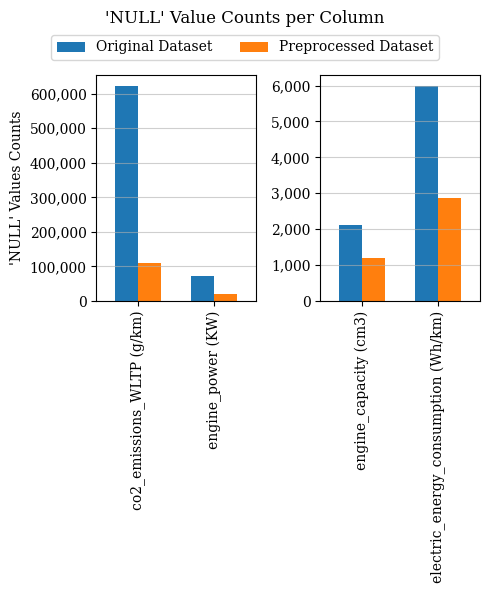

In [592]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df_plot = df_counts.set_index("col")

high_vals = df_plot.loc[["co2_emissions_WLTP (g/km)", "engine_power (KW)"]]
low_vals = df_plot.loc[["engine_capacity (cm3)", "electric_energy_consumption (Wh/km)"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5, 6))

high_vals.plot(kind="bar", ax=ax1, width=0.6, legend=False)
ax1.grid(axis="y", which="major", linestyle="-", alpha=0.6)
ax1.set_xticklabels(high_vals.index, rotation=90, ha="center")
ax1.set_xlabel("")

low_vals.plot(kind="bar", ax=ax2, width=0.6, legend=False)
ax2.grid(axis="y", which="major", linestyle="-", alpha=0.6)
ax2.set_xticklabels(low_vals.index, rotation=90, ha="center")
ax2.set_xlabel("")

ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle("'NULL' Value Counts per Column", y=0.98)
ax1.set_ylabel("'NULL' Values Counts")

handles, labels = ax1.get_legend_handles_labels()
labels = ["Original Dataset", "Preprocessed Dataset"]
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("img/eea_null_counts_per_column.png", dpi=300)
plt.show()
